# PyTorch Autograd: A First Student Notebook

This notebook introduces **automatic differentiation** using PyTorch autograd.

The examples are intentionally small. The aim is to understand how PyTorch records a calculation, how it later applies the chain rule to that record, and how the resulting derivatives can be used in simple scientific and machine-learning calculations.

You do not need to memorize every PyTorch command at once. Focus on the relation between three things:

1. the mathematical function;
2. the numerical code that evaluates the function;
3. the derivative information that automatic differentiation produces.

The code cells are short on purpose. The surrounding text gives the conceptual explanation.

## Prior knowledge

You should be comfortable with basic Python, arrays, and the meaning of a derivative such as

$$
\frac{df}{dx}.
$$

You do **not** need prior experience with neural networks. Autograd is often used in machine learning, but the underlying idea is more general: it is a way to compute derivatives of numerical programs.

# 1. Imports and numerical setup

We use PyTorch for tensor computations and Matplotlib for simple plots. We also use double precision so that small gradient checks are easier to interpret.

In [269]:
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
torch.manual_seed(7)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.5.1


# 2. Why automatic differentiation?

Many scientific and machine-learning problems depend on derivatives. For example, we may want to know how a loss changes when a model parameter changes.

Here are four common ways to compute derivatives:

| Method | Idea | Main limitation |
|---|---|---|
| Hand derivatives | Derive the formula manually | Becomes error-prone for long computations |
| Symbolic differentiation | Manipulate algebraic expressions, often exactly | Expressions can become very large, and it is less convenient for code with loops, conditionals, arrays, or external numerical routines |
| Finite differences | Estimate derivatives by evaluating the function at nearby input values | Sensitive to the perturbation size; costly for many inputs; gives a numerical approximation rather than an exact derivative |
| Automatic differentiation | Apply the chain rule to the operations executed by the program | Requires the computation to be written using differentiable tensor operations |

Automatic differentiation is useful because it computes derivatives through the same sequence of elementary operations that the program actually performs. This is especially helpful when a calculation contains many intermediate variables, array operations, or repeated transformations, where writing and maintaining the derivative by hand would be tedious and error-prone.

### Small exercise: finite-difference error has two regimes

Before moving on to autograd, run the next cell. It uses the same kind of scalar calculation that we will use repeatedly later:

$$
z(x,y)=xy+\sin(x).
$$

We check the derivative with respect to $x$ at $x=2$ and $y=3$. Analytically,

$$
\frac{\partial z}{\partial x}=y+\cos(x).
$$

The exercise is to vary the finite-difference step size $\epsilon$ and observe what happens to the error.

A central finite-difference estimate is

$$
\frac{\partial z}{\partial x}
\approx
\frac{z(x+\epsilon,y)-z(x-\epsilon,y)}{2\epsilon}.
$$

Try to identify the value of $\epsilon$ where the error is smallest.


true derivative = 2.5838531634528574

     epsilon    finite difference     absolute error
     1.0e-01       2.584546394807          6.932e-04
     1.0e-02       2.583860099199          6.936e-06
     1.0e-03       2.583853232811          6.936e-08
     1.0e-04       2.583853164153          7.002e-10
     1.0e-05       2.583853163518          6.520e-11
     1.0e-06       2.583853163429          2.362e-11
     1.0e-07       2.583853162541          9.118e-10
     1.0e-08       2.583853175864          1.241e-08
     1.0e-09       2.583853575544          4.121e-07
     1.0e-10       2.583853131455          3.200e-08
     1.0e-11       2.583844249671          8.914e-06
     1.0e-12       2.584155112118          3.019e-04
     1.0e-13       2.584599201327          7.460e-04
     1.0e-14       2.620126338115          3.627e-02
     1.0e-15       2.664535259100          8.068e-02
     1.0e-16       0.000000000000          2.584e+00

smallest error occurs near epsilon = 1e-06


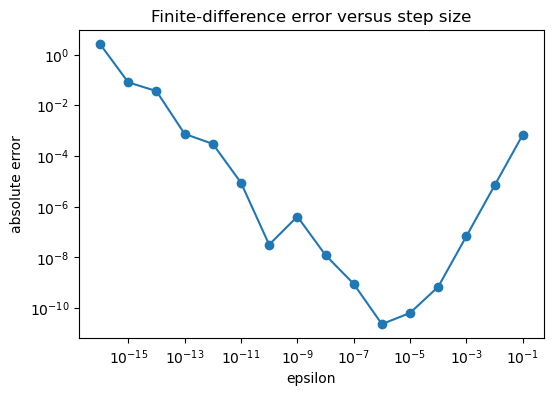

In [270]:
def z_value(x, y):
    return x * y + torch.sin(x)

x0 = torch.tensor(2.0)
y0 = torch.tensor(3.0)

true_derivative = y0 + torch.cos(x0)

eps_values = torch.logspace(-1, -16, steps=16)
fd_values = []
errors = []

for eps in eps_values:
    fd = (z_value(x0 + eps, y0) - z_value(x0 - eps, y0)) / (2 * eps)
    fd_values.append(fd)
    errors.append(torch.abs(fd - true_derivative))

fd_values = torch.stack(fd_values)
errors = torch.stack(errors)

best_index = torch.argmin(errors)

print("true derivative =", true_derivative.item())
print()
print(f"{'epsilon':>12} {'finite difference':>20} {'absolute error':>18}")
for eps, fd, err in zip(eps_values, fd_values, errors):
    print(f"{eps.item():12.1e} {fd.item():20.12f} {err.item():18.3e}")

print()
print("smallest error occurs near epsilon =", eps_values[best_index].item())

plt.figure(figsize=(6, 4))
plt.loglog(eps_values.numpy(), errors.numpy(), marker="o")
plt.xlabel("epsilon")
plt.ylabel("absolute error")
plt.title("Finite-difference error versus step size")
plt.show()


For relatively large $\epsilon$, the finite-difference estimate is inaccurate because the derivative is being approximated over a visibly wide interval. This is **truncation error**.

For extremely small $\epsilon$, the two function evaluations $z(x+\epsilon,y)$ and $z(x-\epsilon,y)$ become nearly equal. Subtracting nearly equal floating-point numbers can lose significant digits. This is **round-off error**.

So finite differences have a practical tension:

- making $\epsilon$ smaller reduces truncation error at first;
- making $\epsilon$ too small increases round-off error.

This is why finite differences are useful for sanity checks, but inconvenient as the main derivative method in large computational graphs.


# 3. What `requires_grad=True` means

Before asking PyTorch for a derivative, we must tell it which tensors should be treated as differentiable inputs.

The statement `requires_grad=True` tells PyTorch:

> Track differentiable operations involving this tensor because I may later ask for derivatives with respect to it.

This does **not** immediately compute a derivative. It only makes the tensor part of PyTorch's autograd bookkeeping.

A useful way to think about it is:

- `requires_grad=True` means "please remember how this tensor influences later quantities";
- `.backward()` means "now use that remembered information to compute derivatives";
- `.grad` is where PyTorch stores the derivative after the backward pass.

This separation is important. A tensor can require gradients for many operations before any derivative is actually computed.

In [271]:
x = torch.tensor(3.0)
y = torch.tensor(3.0, requires_grad=True)

print("x requires grad:", x.requires_grad)
print("y requires grad:", y.requires_grad)

x requires grad: False
y requires grad: True


If a tensor does not require gradients, PyTorch treats it as an ordinary numerical value. If a tensor does require gradients, PyTorch records differentiable operations involving that tensor, so that derivatives can be computed later.

This is the first prerequisite for autograd: PyTorch only tracks a calculation if at least one relevant tensor has `requires_grad=True`.

# 4. First scalar example: what `.backward()` does

Now that we have seen `requires_grad=True`, we can use it in a small derivative calculation.

Consider

$$
z = xy + \sin(x).
$$

The derivatives are

$$
\frac{\partial z}{\partial x} = y + \cos(x),
\qquad
\frac{\partial z}{\partial y} = x.
$$

At $x=2$ and $y=3$, these become

$$
\frac{\partial z}{\partial x} = 3 + \cos(2),
\qquad
\frac{\partial z}{\partial y} = 2.
$$

In PyTorch, we first create `x` and `y` with `requires_grad=True`. Then we compute `z` using ordinary tensor operations. While evaluating this expression, PyTorch records the differentiable operations that connect `x` and `y` to `z`.

The command `z.backward()` should be read as:

> Start from the scalar output `z`, set its sensitivity to itself as $dz/dz=1$, and propagate that sensitivity backward through the recorded graph using the chain rule.

After this backward pass, PyTorch stores $\partial z/\partial x$ in `x.grad` and $\partial z/\partial y$ in `y.grad`, because both `x` and `y` were created with `requires_grad=True`.

So `.backward()` does not update `x` or `y`, and it does not ask us to write the derivative formulas by hand. It computes and stores derivatives of the final scalar with respect to the tracked input tensors, such as `x` and `y` here. The more precise term for such tensors is introduced below.


In [272]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

z = x * y + torch.sin(x)
print("z value =", z.item())

z.backward()

print("dz/dx =", x.grad.item())
print("dz/dy =", y.grad.item())
print("expected dz/dx =", (y + torch.cos(x)).item())
print("expected dz/dy =", x.item())


z value = 6.909297426825682
dz/dx = 2.5838531634528574
dz/dy = 2.0
expected dz/dx = 2.5838531634528574
expected dz/dy = 2.0


The results are stored in `x.grad` and `y.grad`.

The derivative with respect to $x$ has two contributions: one from the product term $xy$ and one from the sine term $\sin(x)$. This is already a useful example of **accumulation inside reverse-mode AD**: when several paths from an input reach the same output, the total derivative is the sum of the contributions from all paths.

At this point, the minimal autograd ingredients are visible:

1. one or more tensors marked with `requires_grad=True`;
2. a scalar quantity computed from those tensors;
3. a call to `.backward()`;
4. the derivatives stored in `.grad` for the tracked input tensors.

The next sections explain the computation graph behind these steps.


# 5. A small computation graph and the chain rule

Autograd records a **computation graph** while tensor operations are evaluated.

For

$$
z = xy + \sin(x),
$$

it is useful to introduce intermediate variables:

$$
a = xy, \qquad b = \sin(x), \qquad z = a + b.
$$

The computation graph is

$$
\begin{aligned}
x,y &\longrightarrow a=xy, \\
x &\longrightarrow b=\sin(x), \\
a,b &\longrightarrow z=a+b.
\end{aligned}
$$

The important feature is that $x$ influences $z$ through two routes. Therefore, the derivative with respect to $x$ is not a single-path derivative. It is a sum of path contributions:

$$
\frac{\partial z}{\partial x}
=
\frac{\partial z}{\partial a}\frac{\partial a}{\partial x}
+
\frac{\partial z}{\partial b}\frac{\partial b}{\partial x}.
$$

Since

$$
\frac{\partial z}{\partial a}=1, \qquad
\frac{\partial a}{\partial x}=y, \qquad
\frac{\partial z}{\partial b}=1, \qquad
\frac{\partial b}{\partial x}=\cos(x),
$$

we get

$$
\frac{\partial z}{\partial x}=y+\cos(x).
$$

Similarly,

$$
\frac{\partial z}{\partial y}
=
\frac{\partial z}{\partial a}\frac{\partial a}{\partial y}
=x.
$$

This is the central idea behind reverse-mode accumulation: if multiple downstream paths depend on the same earlier variable, their derivative contributions are added.


In [273]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

a = x * y
b = torch.sin(x)
z = a + b

print("a = xy =", a.item())
print("b = sin(x) =", b.item())
print("z = a + b =", z.item())

z.backward()

print("dz/dx =", x.grad.item())
print("dz/dy =", y.grad.item())


a = xy = 6.0
b = sin(x) = 0.9092974268256817
z = a + b = 6.909297426825682
dz/dx = 2.5838531634528574
dz/dy = 2.0


# 6. The graph is dynamic

PyTorch uses a dynamic computation graph. This means the graph is built from the actual operations executed in Python.

If Python takes a different branch, PyTorch records a different graph.

This is one reason autograd is convenient for numerical code: the derivative follows the computation that actually happened in that run, including loops, branches, and tensor operations, as long as the operations remain differentiable and tracked by PyTorch.

This section comes early because it clarifies what PyTorch is differentiating: not a separate symbolic formula, but the executed tensor computation.

In [274]:
def simple_branch(theta):
    if theta.item() > 0:
        return theta**2
    else:
        return -theta

for value in [2.0, -2.0]:
    theta = torch.tensor(value, requires_grad=True)
    loss = simple_branch(theta)
    loss.backward()
    print(f"theta = {value: .1f}, loss = {loss.item(): .1f}, gradient = {theta.grad.item(): .1f}")

theta =  2.0, loss =  4.0, gradient =  4.0
theta = -2.0, loss =  2.0, gradient = -1.0


For $\theta=2$, the executed function is $L=\theta^2$, so the derivative is $4$.  
For $\theta=-2$, the executed function is $L=-\theta$, so the derivative is $-1$.

Autograd follows the computation that actually happened.

# 7. Leaf tensors and intermediate tensors

Now that we have used `.grad`, we need to clarify where PyTorch stores gradients.

A **leaf tensor** is a tensor that is created directly by the user, rather than being produced by another differentiable tensor operation. Model parameters are usually leaf tensors.

Intermediate tensors are produced by operations. In the example

$$
a=xy, \qquad b=\sin(x), \qquad z=a+b,
$$

`x` and `y` are leaf tensors, while `a`, `b`, and `z` are intermediate tensors.

PyTorch normally stores `.grad` only for leaf tensors that require gradients. This is why `x.grad` and `y.grad` appear after `.backward()`, while `a.grad` and `b.grad` are not stored by default.

This can be surprising at first: intermediate tensors do participate in the backward calculation, but their gradients are usually not retained after the calculation unless we explicitly ask for them.


In [275]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

a = x * y
b = torch.sin(x)
z = a + b

print("x is leaf:", x.is_leaf)
print("y is leaf:", y.is_leaf)
print("a is leaf:", a.is_leaf)
print("b is leaf:", b.is_leaf)
print("z is leaf:", z.is_leaf)

print("x.grad_fn =", x.grad_fn)
print("a.grad_fn =", a.grad_fn)
print("b.grad_fn =", b.grad_fn)
print("z.grad_fn =", z.grad_fn)

z.backward()

print("x.grad =", x.grad)
print("y.grad =", y.grad)

print("a.grad =", a.grad)
print("b.grad =", b.grad)


x is leaf: True
y is leaf: True
a is leaf: False
b is leaf: False
z is leaf: False
x.grad_fn = None
a.grad_fn = <MulBackward0 object at 0x7c83e1b6d4c0>
b.grad_fn = <SinBackward0 object at 0x7c83e1b7a8b0>
z.grad_fn = <AddBackward0 object at 0x7c83e1b6d4c0>
x.grad = tensor(2.5839)
y.grad = tensor(2.)
a.grad = None
b.grad = None


/tmp/ipykernel_16240/160298425.py:24: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647380992/work/build/aten/src/ATen/core/TensorBody.h:489.)
  print("a.grad =", a.grad)
/tmp/ipykernel_16240/160298425.py:25: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the lea

The attribute `grad_fn` shows which differentiable operation produced a tensor. Leaf tensors such as `x` and `y` have `grad_fn=None`, because they were created directly by the user. Intermediate tensors such as `a`, `b`, and `z` have a `grad_fn`, because PyTorch knows which operation created them and can therefore use that operation during the backward pass.

Usually, you do not need to inspect `grad_fn` during normal work. It is mainly useful for developing the mental model and for debugging.

# 8. Retaining an intermediate gradient

Sometimes, for debugging or learning, we may want to inspect the gradient of an intermediate tensor. PyTorch can do this if we explicitly call `.retain_grad()`.

This does not change the derivative calculation itself. It only tells PyTorch to keep an extra value that it would normally discard to save memory.

For $z=a+b$, the intermediate sensitivities should be simple:

$$
\frac{\partial z}{\partial a}=1,
\qquad
\frac{\partial z}{\partial b}=1.
$$

The gradients with respect to `x` and `y` are different because they require propagating these intermediate sensitivities further backward through $a=xy$ and $b=\sin(x)$.


In [276]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

a = x * y
b = torch.sin(x)

a.retain_grad()
b.retain_grad()

z = a + b
z.backward()

print("dz/da =", a.grad.item())
print("dz/db =", b.grad.item())
print("dz/dx =", x.grad.item())
print("dz/dy =", y.grad.item())


dz/da = 1.0
dz/db = 1.0
dz/dx = 2.5838531634528574
dz/dy = 2.0


Here `a.grad` is $\partial z/\partial a$ and `b.grad` is $\partial z/\partial b$. Both are equal to $1$ because $z=a+b$.

The gradient `x.grad` is larger in structure because $x$ feeds into both `a` and `b`. Reverse mode accumulates both contributions:

$$
\frac{\partial z}{\partial x}
=
\underbrace{y}_{\text{from }xy}
+
\underbrace{\cos(x)}_{\text{from }\sin(x)}.
$$

This is different from `y.grad`, which only receives a contribution from the product path $xy$.


# 9. The same graph is usually used once

After `.backward()` is called, PyTorch usually frees parts of the computation graph. This saves memory.

This matters because the graph stores intermediate values needed for the backward pass. Once those saved values are released, PyTorch cannot simply run the same backward pass again.

Therefore, if we try to call `.backward()` a second time on the same loss, it usually fails. The usual solution is not to reuse the old graph. Instead, recompute the loss from the current tensor values and call `.backward()` on the new loss.

The practical rule is: **new derivative calculation, new forward calculation**.

In [277]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

z = x * y + torch.sin(x)

z.backward()
print("First backward succeeded.")

try:
    z.backward()
except RuntimeError as err:
    print("Second backward failed as expected.")
    print(str(err).split("\n")[0])


First backward succeeded.
Second backward failed as expected.
Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.


For a first notebook, the safest habit is simple:

> Recompute the loss before requesting a new backward calculation.

There are advanced cases where one can keep the graph, but that is not the default behavior.

# 10. Gradients accumulate

The word **accumulate** appears in two related but distinct places.

First, inside one reverse-mode pass, derivative contributions from different paths are added. In

$$
z=xy+\sin(x),
$$

$x$ reaches $z$ through both $xy$ and $\sin(x)$, so the total derivative is

$$
\frac{\partial z}{\partial x}=y+\cos(x).
$$

Second, PyTorch also accumulates gradients into the `.grad` attribute across multiple calls to `.backward()`. That means PyTorch **adds** new gradients into `.grad`; it does not automatically erase the old value.

This is intentional. In some training setups, one may want to accumulate gradients across several mini-batches before updating the parameters.

For a first notebook, however, it is usually a source of confusion. If you call `.backward()` repeatedly without clearing `.grad`, the stored gradient will be the sum of all backward calls so far, not just the most recent derivative.


In [278]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

z = x * y + torch.sin(x)
z.backward()
print("after first backward call:")
print("x.grad =", x.grad.item())
print("y.grad =", y.grad.item())

# Recompute z and call backward again.
z = x * y + torch.sin(x)
z.backward()
print("\nafter second backward call:")
print("x.grad =", x.grad.item())
print("y.grad =", y.grad.item())


after first backward call:
x.grad = 2.5838531634528574
y.grad = 2.0

after second backward call:
x.grad = 5.167706326905715
y.grad = 4.0


At $x=2$ and $y=3$, the derivative with respect to $x$ is $3+\cos(2)$, and the derivative with respect to $y$ is $2$.

After two backward calls, `.grad` contains twice those values, because the new gradients were added to the old stored gradients.

This is different from the path accumulation inside a single backward pass. Path accumulation is mathematically required by the chain rule. `.grad` accumulation across multiple backward calls is PyTorch's storage behavior.

Before computing a fresh gradient, reset the old gradient.


In [279]:
x.grad = None
y.grad = None

z = x * y + torch.sin(x)
z.backward()

print("After resetting grad:")
print("x.grad =", x.grad.item())
print("y.grad =", y.grad.item())


After resetting grad:
x.grad = 2.5838531634528574
y.grad = 2.0


Using `theta.grad = None` is a common and efficient way to clear the stored gradient for a tensor.

# 11. `torch.no_grad()`

The context manager `torch.no_grad()` temporarily turns off gradient tracking.

This is useful when updating parameters, evaluating a model, or computing quantities that should not become part of the graph.

The difference from `detach()` is mainly scope. `detach()` disconnects a particular tensor from its history. `torch.no_grad()` says that all operations inside the block should be performed without recording a graph.

We introduce `no_grad()` before the parameter-update example because parameter updates are numerical bookkeeping steps. They should change the parameter values, but they should not themselves become part of the differentiable model.

In [280]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

with torch.no_grad():
    z = x * y + torch.sin(x)

print("x requires grad:", x.requires_grad)
print("y requires grad:", y.requires_grad)
print("z requires grad:", z.requires_grad)


x requires grad: True
y requires grad: True
z requires grad: False


The original tensor `theta` still requires gradients. Only the operations performed inside the `no_grad` block were not tracked.

# 12. Parameter updates are separate from autograd

Autograd computes derivatives. It does not decide how to update parameters.

To connect optimization with the same example, suppose we want the scalar

$$
z=xy+\sin(x)
$$

to match a target value $z_\mathrm{target}$. A simple loss is

$$
L=(z-z_\mathrm{target})^2.
$$

Now $x$ and $y$ are parameters, and the loss depends on them through the differentiable calculation of $z$.

A simple gradient-descent update has the form

$$
x \leftarrow x - \eta \frac{\partial L}{\partial x},
\qquad
y \leftarrow y - \eta \frac{\partial L}{\partial y},
$$

where $\eta$ is the learning rate.

The update itself should not be recorded as part of the differentiable graph. Otherwise PyTorch would start tracking the optimization step as if it were part of the model whose derivatives we later want.

Therefore, we perform the update inside `torch.no_grad()`, which was introduced in the previous section. This says: use the numerical gradient values to change the parameters, but do not build a new autograd graph for the update operation.


In [281]:
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(1.0, requires_grad=True)

target = torch.tensor(4.0)
learning_rate = 0.05

for step in range(12):
    z = x * y + torch.sin(x)
    loss = (z - target)**2
    loss.backward()

    with torch.no_grad():
        x -= learning_rate * x.grad
        y -= learning_rate * y.grad

    x.grad = None
    y.grad = None
    print(
        f"step {step:2d}: x = {x.item():.4f}, "
        f"y = {y.item():.4f}, z = {z.item():.4f}, loss = {loss.item():.4f}"
    )


step  0: x = 1.3325, y = 1.2159, z = 1.8415, loss = 4.6592
step  1: x = 1.5369, y = 1.4035, z = 2.5918, loss = 1.9829
step  2: x = 1.6582, y = 1.5331, z = 3.1565, loss = 0.7115
step  3: x = 1.7249, y = 1.6097, z = 3.5384, loss = 0.2131
step  4: x = 1.7592, y = 1.6503, z = 3.7647, loss = 0.0554
step  5: x = 1.7759, y = 1.6704, z = 3.8854, loss = 0.0131
step  6: x = 1.7839, y = 1.6801, z = 3.9456, loss = 0.0030
step  7: x = 1.7877, y = 1.6846, z = 3.9745, loss = 0.0006
step  8: x = 1.7894, y = 1.6867, z = 3.9881, loss = 0.0001
step  9: x = 1.7902, y = 1.6877, z = 3.9945, loss = 0.0000
step 10: x = 1.7906, y = 1.6882, z = 3.9974, loss = 0.0000
step 11: x = 1.7908, y = 1.6884, z = 3.9988, loss = 0.0000


The parameters move so that $z=xy+\sin(x)$ gets closer to the target value.

This example separates three ideas:

1. The differentiable calculation produces $z$ and then the scalar loss.
2. `.backward()` computes the derivatives of the loss with respect to `x` and `y`.
3. The update rule changes the parameter values.

Autograd supplies the gradients. The choice of update rule is a separate optimization decision.


# 13. Two directions for the chain rule

So far, `.backward()` has shown us PyTorch's most common derivative calculation: start from a scalar output and propagate sensitivities backward. This is reverse-mode automatic differentiation.

The same computation graph can also be differentiated in a forward direction.

For

$$
a=xy, \qquad b=\sin(x), \qquad z=a+b,
$$

the ordinary numerical values move from inputs to output. Automatic differentiation can attach derivative information to this calculation in two ways.

| Mode | What is propagated? | Direction | Typical product |
|---|---|---|---|
| Forward mode | Tangents, such as $\dot{x}$ and $\dot{z}$ | Input to output | Jacobian-vector product, $Jv$ |
| Reverse mode | Adjoints or sensitivities, such as $\bar{z}$ and $\bar{x}$ | Output to input | Vector-Jacobian product, $\mathbf{w}^T J$ |

Both modes are applications of the chain rule. The difference is not the mathematics, but the direction in which derivative information is propagated.

Forward mode starts by asking: **if I perturb the input in this direction, how does the output change?**

Reverse mode starts by asking: **if I care about this final output, how sensitive is it to each earlier quantity?**

This distinction matters when the input and output have different sizes. Forward mode is natural when we want derivatives along a small number of input directions. Reverse mode is natural when many inputs affect one scalar output, which is the usual situation in model training.


# 14. Forward-mode AD: propagating tangents

In **forward-mode automatic differentiation**, each quantity carries two pieces of information.

| Quantity | Meaning |
|---|---|
| **Primal** | The ordinary numerical value |
| **Tangent** | The directional derivative of that value |

The tangent is not a finite-difference perturbation. It is derivative information propagated exactly through the same elementary operations as the primal value.

For the example

$$
a=xy, \qquad b=\sin(x), \qquad z=a+b,
$$

we choose input tangents. If we want $\partial z/\partial x$ while keeping $y$ fixed, we seed

$$
\dot{x}=1, \qquad \dot{y}=0.
$$

Forward mode then propagates tangents in the same order as the primal calculation:

$$
\dot{a} = \dot{x}y + x\dot{y},
$$

$$
\dot{b}=\cos(x)\dot{x},
$$

and

$$
\dot{z}=\dot{a}+\dot{b}.
$$

At $x=2$ and $y=3$, this gives

$$
\dot{z}=3+\cos(2),
$$

which is $\partial z/\partial x$ for this seed direction.

The key idea is: **forward mode pushes input derivative information forward through the computation and reports the resulting output derivative information**.


In [282]:
x = torch.tensor(2.0)
y = torch.tensor(3.0)

x_dot = torch.tensor(1.0)  # seed for dz/dx
y_dot = torch.tensor(0.0)  # keep y fixed

# Primal calculation
a = x * y
b = torch.sin(x)
z = a + b

# Tangent calculation
a_dot = x_dot * y + x * y_dot
b_dot = torch.cos(x) * x_dot
z_dot = a_dot + b_dot

print("primal a =", a.item())
print("primal b =", b.item())
print("primal z =", z.item())
print("tangent a_dot =", a_dot.item())
print("tangent b_dot =", b_dot.item())
print("tangent z_dot =", z_dot.item())


primal a = 6.0
primal b = 0.9092974268256817
primal z = 6.909297426825682
tangent a_dot = 3.0
tangent b_dot = -0.4161468365471424
tangent z_dot = 2.5838531634528574


PyTorch can compute the same forward-mode result using `torch.func.jvp`. Here, `jvp` means **Jacobian-vector product**.

The function returns two things:

1. the ordinary output value;
2. the tangent of the output in the chosen input direction.

For the scalar function $z=f(x,y)$, the Jacobian is a row vector,

$$
J =
\begin{bmatrix}
\partial z/\partial x & \partial z/\partial y
\end{bmatrix}.
$$

If the input tangent is $\mathbf{v}=(1,0)$, then $J\mathbf{v}$ extracts the change in $z$ when only $x$ is perturbed. If the input tangent is $\mathbf{v}=(0,1)$, it extracts the change in $z$ when only $y$ is perturbed.

A useful point is that `jvp` does not require us to form the full Jacobian. It directly computes how the output changes along the one input direction we supplied.


In [283]:
def scalar_z(inputs):
    x, y = inputs
    return x * y + torch.sin(x)

inputs = torch.tensor([2.0, 3.0])
v = torch.tensor([1.0, 0.0])  # direction: change x, keep y fixed

value, tangent = torch.func.jvp(scalar_z, (inputs,), (v,))

print("z =", value.item())
print("input direction v =", v)
print("Jv =", tangent.item())


z = 6.909297426825682
input direction v = tensor([1., 0.])
Jv = 2.5838531634528574


For vector inputs, the input tangent is a direction vector.

If

$$
\mathbf{y} = f(\mathbf{x}),
$$

and the input tangent is $\mathbf{v}$, then one forward-mode run computes

$$
J\mathbf{v},
$$

where $J$ is the Jacobian of $f$.

To keep the same example, write the two pieces of $z=xy+\sin(x)$ as a vector-valued function:

$$
f(x,y)=
\begin{bmatrix}
xy \\
\sin(x)
\end{bmatrix}.
$$

The scalar $z$ is the sum of these two components. A JVP through this vector function tells us how each component changes along the chosen input direction.

For first-time use, it helps to read $J\mathbf{v}$ as: "push this input direction through the function."


In [284]:
def component_function(inputs):
    x, y = inputs
    return torch.stack([
        x * y,
        torch.sin(x)
    ])

inputs = torch.tensor([2.0, 3.0])
v = torch.tensor([0.5, -1.0])  # input direction

components, jvp = torch.func.jvp(component_function, (inputs,), (v,))

print("components [xy, sin(x)] =", components)
print("input direction v =", v)
print("Jv =", jvp)
print("change in z along v = sum(Jv) =", jvp.sum().item())


components [xy, sin(x)] = tensor([6.0000, 0.9093])
input direction v = tensor([ 0.5000, -1.0000])
Jv = tensor([-0.5000, -0.2081])
change in z along v = sum(Jv) = -0.7080734182735712


For this function,

$$
f(x,y)=
\begin{bmatrix}
xy \\
\sin(x)
\end{bmatrix}.
$$

The Jacobian is

$$
J=
\begin{bmatrix}
y & x \\
\cos(x) & 0
\end{bmatrix}.
$$

At $x=2$ and $y=3$,

$$
J=
\begin{bmatrix}
3 & 2 \\
\cos(2) & 0
\end{bmatrix}.
$$

For $\mathbf{v}=(0.5,-1)$,

$$
J\mathbf{v}
=
\begin{bmatrix}
3 & 2 \\
\cos(2) & 0
\end{bmatrix}
\begin{bmatrix}
0.5 \\
-1
\end{bmatrix}.
$$

The first component is the directional change of $xy$, and the second component is the directional change of $\sin(x)$. Their sum is the directional change of $z=xy+\sin(x)$.


### Exercise: change the JVP direction

In the code above, change the direction vector `v`.

Try

```python
v = torch.tensor([1.0, 0.0])
```

and then

```python
v = torch.tensor([0.0, 1.0])
```

The first choice asks how the two components $xy$ and $\sin(x)$ change when only $x$ changes. The second choice asks how they change when only $y$ changes.

These two choices isolate the first and second columns of the Jacobian. This is one way to build intuition for why repeated JVPs can recover a full Jacobian column by column.


# 15. Reverse-mode AD: propagating adjoints

Reverse mode applies the same chain rule, but in the opposite direction.

Instead of starting with an input tangent, reverse mode starts from the output. For a scalar output $z$, we seed the output sensitivity as

$$
\bar{z}=1.
$$

This is the statement that $dz/dz=1$: the output changes one-for-one with itself.

The bar notation denotes an **adjoint** or **sensitivity**. It answers the question:

> If this intermediate quantity changed slightly, how much would the final scalar output change?

For

$$
a=xy, \qquad b=\sin(x), \qquad z=a+b,
$$

reverse mode starts from $\bar{z}=1$ and propagates backward:

$$
\bar{a}=\bar{z}\frac{\partial z}{\partial a}=1,
\qquad
\bar{b}=\bar{z}\frac{\partial z}{\partial b}=1.
$$

Then the sensitivity with respect to $x$ receives contributions from both $a$ and $b$:

$$
\bar{x}
=
\bar{a}\frac{\partial a}{\partial x}
+
\bar{b}\frac{\partial b}{\partial x}
=
y+\cos(x).
$$

The sensitivity with respect to $y$ receives only the product contribution:

$$
\bar{y}
=
\bar{a}\frac{\partial a}{\partial y}
=x.
$$

This is the accumulation concept in reverse mode: when two backward paths reach the same variable, their contributions are added.


In [285]:
x = torch.tensor(2.0)
y = torch.tensor(3.0)

# Primal calculation
a = x * y
b = torch.sin(x)
z = a + b

# Reverse-mode sensitivity calculation
z_bar = torch.tensor(1.0)        # dz/dz

a_bar = z_bar * 1.0              # dz/da
b_bar = z_bar * 1.0              # dz/db

x_bar_from_a = a_bar * y         # contribution through a = xy
x_bar_from_b = b_bar * torch.cos(x)  # contribution through b = sin(x)
x_bar = x_bar_from_a + x_bar_from_b

y_bar = a_bar * x                # contribution through a = xy

print("primal a =", a.item())
print("primal b =", b.item())
print("primal z =", z.item())
print("x contribution from xy =", x_bar_from_a.item())
print("x contribution from sin(x) =", x_bar_from_b.item())
print("x_bar = dz/dx =", x_bar.item())
print("y_bar = dz/dy =", y_bar.item())


primal a = 6.0
primal b = 0.9092974268256817
primal z = 6.909297426825682
x contribution from xy = 3.0
x contribution from sin(x) = -0.4161468365471424
x_bar = dz/dx = 2.5838531634528574
y_bar = dz/dy = 2.0


The manual calculation above is exactly the kind of chain-rule propagation that `.backward()` automates.

When we call `z.backward()`, PyTorch treats `z` as the final scalar whose sensitivity is $1$. It then walks backward through the operations that produced `z`, multiplying by local derivatives. When several paths meet at the same earlier tensor, PyTorch adds the contributions.

For this graph, the two contributions to $x$ are

$$
\underbrace{y}_{\text{from }xy}
\qquad \text{and} \qquad
\underbrace{\cos(x)}_{\text{from }\sin(x)}.
$$

Therefore,

$$
\frac{\partial z}{\partial x}=y+\cos(x).
$$

This is the accumulation concept during one reverse-mode pass. It should not be confused with the separate PyTorch storage behavior where repeated calls to `.backward()` add new values into `.grad` unless the old gradients are cleared.

Reverse mode is especially important when the output is a scalar loss and the input contains many parameters. One reverse pass can compute the gradient of that scalar loss with respect to all parameters. This is why reverse-mode AD is central to neural-network training and many parameter-estimation problems.


# 16. `torch.autograd.grad`: returning gradients directly

The method `.backward()` stores gradients in `.grad`. This is convenient for model training, where parameters repeatedly receive gradients and an optimizer reads them.

Sometimes we do not want to store gradients inside the tensors. We simply want a derivative as an ordinary returned tensor, perhaps for analysis, diagnostics, or a custom calculation. For that, PyTorch provides `torch.autograd.grad`.

A useful distinction is:

- `.backward()` means "compute gradients and accumulate them into `.grad`";
- `torch.autograd.grad` means "compute these gradients and return them to me directly."

In [286]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

z = x * y + torch.sin(x)

grad_x, grad_y = torch.autograd.grad(z, (x, y))

print("returned dz/dx =", grad_x.item())
print("returned dz/dy =", grad_y.item())
print("x.grad =", x.grad)
print("y.grad =", y.grad)


returned dz/dx = 2.5838531634528574
returned dz/dy = 2.0
x.grad = None
y.grad = None


The result is returned directly instead of being stored in `.grad`.

Notice that `x.grad` and `y.grad` remain `None`. The derivatives were computed, but they were returned as ordinary tensors rather than accumulated into the leaf tensors.

This is useful when gradients are needed for analysis or for a custom calculation, but we do not want to modify the `.grad` fields.


# 17. Vector inputs and a scalar output

In scientific computing, parameters often come as a vector. The same idea still applies.

Let

$$
\boldsymbol{\theta}=
\begin{bmatrix}
x \\
y
\end{bmatrix},
\qquad
z(\boldsymbol{\theta}) = xy + \sin(x).
$$

Then

$$
\nabla_{\boldsymbol{\theta}} z
=
\begin{bmatrix}
y+\cos(x) \\
x
\end{bmatrix}.
$$

Here the output is still a scalar, so `.backward()` has a clear default meaning: compute the gradient of that scalar with respect to every component of the input vector.


In [287]:
theta = torch.tensor([2.0, 3.0], requires_grad=True)

x, y = theta[0], theta[1]
z = x * y + torch.sin(x)
z.backward()

print("theta =", theta)
print("gradient =", theta.grad)


theta = tensor([2., 3.], requires_grad=True)
gradient = tensor([2.5839, 2.0000])


The gradient has the same shape as `theta`. The first entry is $\partial z/\partial x$, and the second entry is $\partial z/\partial y$.

This vector form is closer to how parameters are usually represented in PyTorch models.


# 18. Vector outputs and vector-Jacobian products

When the output is a scalar, `.backward()` knows what derivative we want: the gradient of that scalar with respect to the inputs.

When the output is a vector, there is not one unique scalar derivative. A vector output has many components, and each component may have its own gradient with respect to the input.

To connect this to the same example, split

$$
z=xy+\sin(x)
$$

into two output components:

$$
\mathbf{q}=f(x,y)=
\begin{bmatrix}
q_1 \\
q_2
\end{bmatrix}
=
\begin{bmatrix}
xy \\
\sin(x)
\end{bmatrix}.
$$

If we choose weights

$$
\mathbf{w}=\begin{bmatrix}1 \\ 1\end{bmatrix},
$$

then

$$
\mathbf{w}^T\mathbf{q}=xy+\sin(x)=z.
$$

For a general weight vector $\mathbf{w}$, the vector-Jacobian product with respect to the input is

$$
\mathbf{w}^T J,
$$

where $J$ is the Jacobian of $f$. This is called a **vector-Jacobian product** or **VJP**.

PyTorch supplies $\mathbf{w}$ through `grad_outputs` and returns $\mathbf{w}^T J$. For first-time use, it helps to read $\mathbf{w}^T J$ as: "pull this output weighting backward through the function."


In [288]:
inputs = torch.tensor([2.0, 3.0], requires_grad=True)
x, y = inputs[0], inputs[1]

q = torch.stack([
    x * y,
    torch.sin(x)
])

w = torch.tensor([1.0, 1.0])

vjp = torch.autograd.grad(q, inputs, grad_outputs=w)[0]

print("q = [xy, sin(x)] =", q)
print("output weights w =", w)
print("w^T J =", vjp)


q = [xy, sin(x)] = tensor([6.0000, 0.9093], grad_fn=<StackBackward0>)
output weights w = tensor([1., 1.])
w^T J = tensor([2.5839, 2.0000])


Here `q` has two components. The vector `w` tells PyTorch to differentiate the scalar combination

$$
s = w_1 q_1 + w_2 q_2.
$$

For $\mathbf{w}=(1,1)$, this scalar is

$$
s=xy+\sin(x)=z.
$$

The Jacobian of $\mathbf{q}$ is

$$
J=
\begin{bmatrix}
y & x \\
\cos(x) & 0
\end{bmatrix}.
$$

Therefore,

$$
\mathbf{w}^T J
=
\begin{bmatrix}
1 & 1
\end{bmatrix}
\begin{bmatrix}
y & x \\
\cos(x) & 0
\end{bmatrix}
=
\begin{bmatrix}
y+\cos(x) & x
\end{bmatrix}.
$$

This is exactly the gradient of $z=xy+\sin(x)$. The VJP form makes the reverse-mode accumulation explicit: the first input receives contributions from both output components.


### Exercise: change the VJP weights

In the code above, change the output-weight vector `w`.

Try

```python
w = torch.tensor([1.0, 0.0])
```

and then

```python
w = torch.tensor([0.0, 1.0])
```

The first choice asks for the gradient of $xy$ alone. The second choice asks for the gradient of $\sin(x)$ alone.

Then return to

```python
w = torch.tensor([1.0, 1.0])
```

and observe that the gradient is the sum of the two separate contributions. This is the same accumulation idea seen in `.backward()`.


# 19. Full Jacobians

A Jacobian contains all first derivatives of a vector-valued function.

For

$$
\mathbf{q}=f(x,y)=
\begin{bmatrix}
xy \\
\sin(x)
\end{bmatrix},
$$

the Jacobian is

$$
J_{ij}=\frac{\partial q_i}{\partial \theta_j},
\qquad
\boldsymbol{\theta}=\begin{bmatrix}x \\ y\end{bmatrix}.
$$

The rows correspond to output components, and the columns correspond to input components.

PyTorch can compute full Jacobians directly. Two common transforms are:

| Transform | Mode used internally | Often natural when |
|---|---|---|
| `torch.func.jacfwd` | Forward mode | Few inputs, many outputs |
| `torch.func.jacrev` | Reverse mode | Many inputs, few outputs |

For this small example both give the same Jacobian.

Conceptually, a full Jacobian can be assembled from repeated products: repeated JVPs reveal columns, while repeated VJPs reveal rows. In real large-scale problems, we often avoid forming the full matrix unless we truly need it.


In [289]:
def f(theta):
    x, y = theta
    return torch.stack([
        x * y,
        torch.sin(x)
    ])

theta = torch.tensor([2.0, 3.0])

J_forward = torch.func.jacfwd(f)(theta)
J_reverse = torch.func.jacrev(f)(theta)

print("Jacobian from jacfwd:")
print(J_forward)

print("\nJacobian from jacrev:")
print(J_reverse)


Jacobian from jacfwd:
tensor([[ 3.0000,  2.0000],
        [-0.4161, -0.0000]])

Jacobian from jacrev:
tensor([[ 3.0000,  2.0000],
        [-0.4161,  0.0000]])


For this function, the Jacobian should be

$$
J=
\begin{bmatrix}
y & x \\
\cos(x) & 0
\end{bmatrix}.
$$

At $x=2$ and $y=3$, this becomes

$$
J=
\begin{bmatrix}
3 & 2 \\
\cos(2) & 0
\end{bmatrix}.
$$

The main point is not to memorize every Jacobian tool. The main point is to recognize the structure:

- a JVP computes $J\mathbf{v}$ without necessarily forming $J$;
- a VJP computes $\mathbf{w}^T J$ without necessarily forming $J$;
- a full Jacobian stores all entries $J_{ij}$.

In large problems, forming the full Jacobian can be unnecessary and expensive. Products such as $J\mathbf{v}$ and $\mathbf{w}^T J$ are often the quantities we actually need.

The next section shows a different use of autograd: differentiating a derivative itself.


# 20. Higher derivatives

Autograd can also differentiate derivatives.

Using the same scalar example,

$$
z(x,y)=xy+\sin(x),
$$

treat $y$ as fixed and differentiate with respect to $x$. Then

$$
\frac{\partial z}{\partial x}=y+\cos(x),
$$

and

$$
\frac{\partial^2 z}{\partial x^2}=-\sin(x).
$$

The subtle point is that a derivative is normally returned as a numerical tensor, not as a new differentiable computation. To compute a second derivative, the first derivative must itself remain connected to a graph. This is why we use `create_graph=True`.

In words, `create_graph=True` means: do not treat the first derivative as the end of the calculation; keep enough graph information so that this derivative can be differentiated again.


In [290]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0)

z = x * y + torch.sin(x)
first_derivative = torch.autograd.grad(z, x, create_graph=True)[0]
second_derivative = torch.autograd.grad(first_derivative, x)[0]

print("first derivative dz/dx =", first_derivative.item())
print("second derivative d2z/dx2 =", second_derivative.item())
print("expected second derivative =", (-torch.sin(x)).item())


first derivative dz/dx = 2.5838531634528574
second derivative d2z/dx2 = -0.9092974268256817
expected second derivative = -0.9092974268256817


At $x=2$, the first derivative is $3+\cos(2)$, and the second derivative is $-\sin(2)$.


# 21. A small fitting problem

We now use autograd for a simple parameter-fitting problem.

Suppose the data approximately follow a straight-line model

$$
y = ax + b.
$$

The parameters are $a$ and $b$. We choose them by minimizing the mean squared error between the model prediction and the observed data.

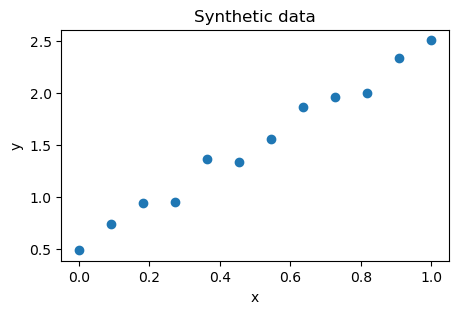

In [291]:
x_data = torch.linspace(0.0, 1.0, 12)
y_data = 2.0 * x_data + 0.5 + 0.08 * torch.randn_like(x_data)

plt.figure(figsize=(5, 3))
plt.scatter(x_data, y_data)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic data")
plt.show()

We start from an incorrect guess for $a$ and $b$, compute the prediction, and define the loss.

At this stage, the computation graph connects the parameters `a` and `b` to the scalar `loss`. Calling `.backward()` then tells us how changing each parameter would change the loss at the current parameter values.


In [292]:
a = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

prediction = a * x_data + b
loss = torch.mean((prediction - y_data)**2)

loss.backward()

print("initial loss =", loss.item())
print("dL/da =", a.grad.item())
print("dL/db =", b.grad.item())

initial loss = 2.6537411867161094
dL/da = -1.8923902767433012
dL/db = -3.014013416151003


The gradients tell us how the loss responds to changes in the parameters. A gradient-descent loop repeatedly uses these derivatives to improve the parameters.

Each iteration has the same structure:

1. compute the current loss from the current parameters;
2. call `.backward()` to compute gradients;
3. update the parameters without tracking the update in the graph;
4. clear the old gradients before the next iteration.

This is the basic pattern behind many PyTorch training loops.


In [293]:
a = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

learning_rate = 0.4
loss_history = []

for step in range(60):
    prediction = a * x_data + b
    loss = torch.mean((prediction - y_data)**2)
    loss.backward()

    with torch.no_grad():
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad

    a.grad = None
    b.grad = None
    loss_history.append(loss.item())

print("fitted a =", a.item())
print("fitted b =", b.item())
print("final loss =", loss_history[-1])

fitted a = 1.9288079259652091
fitted b = 0.5437683723013723
final loss = 0.005746172856563626


The fitted values should be close to the values used to generate the data: $a\approx 2$ and $b\approx 0.5$. They will not be exact because we added noise.

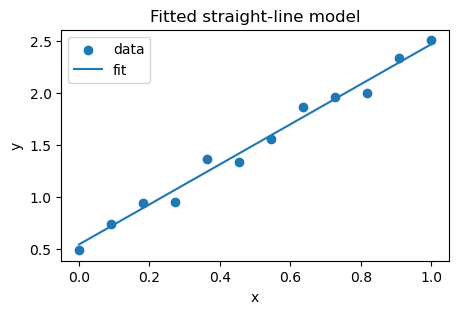

In [294]:
with torch.no_grad():
    fitted_line = a * x_data + b

plt.figure(figsize=(5, 3))
plt.scatter(x_data, y_data, label="data")
plt.plot(x_data, fitted_line, label="fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Fitted straight-line model")
plt.show()

# 22. The same fit with a PyTorch optimizer

In real PyTorch code, parameter updates are usually handled by an optimizer.

The optimizer does not replace autograd. Autograd computes the gradients, and the optimizer uses those gradients to update the parameters.

A typical iteration computes the loss, clears old gradients with `optimizer.zero_grad()`, calls `.backward()`, and then updates the parameters with `optimizer.step()`.

The order matters. Clearing old gradients before the backward pass ensures that the gradients used by `optimizer.step()` come from the current loss, not from previous iterations.

In [295]:
params = torch.nn.Parameter(torch.tensor([0.0, 0.0]))
optimizer = torch.optim.SGD([params], lr=0.4)

for step in range(60):
    a, b = params[0], params[1]
    prediction = a * x_data + b
    loss = torch.mean((prediction - y_data)**2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print("fitted a =", params[0].item())
print("fitted b =", params[1].item())

fitted a = 1.9288079259652091
fitted b = 0.5437683723013723


This is the standard training pattern in PyTorch. The conceptual pieces are the same as before; the optimizer simply organizes the update step.

# 23. A small differentiable forward model

Autograd is not limited to straight lines or neural networks. Any differentiable PyTorch computation can be used as a forward model.

As a simple example, consider an exponential-decay model

$$
y(t) = A\exp(-t/\tau),
$$

where $A$ is an amplitude and $\tau$ is a characteristic time-scale. We can ask how the model output changes with respect to $\tau$.

The important idea is that the model can contain several tensor operations: division, exponentiation, multiplication, and averaging. PyTorch records these operations and applies the chain rule through all of them.

In [296]:
t = torch.linspace(0.0, 4.0, 6)
A = torch.tensor(3.0)
tau = torch.tensor(2.0, requires_grad=True)

y = A * torch.exp(-t / tau)
summary = torch.mean(y)
summary.backward()

print("model output =", y)
print("d mean(y) / d tau =", tau.grad.item())

model output = tensor([3.0000, 2.0110, 1.3480, 0.9036, 0.6057, 0.4060],
       grad_fn=<MulBackward0>)
d mean(y) / d tau = 0.3956823098168374


The scalar `summary` is a simple summary statistic of the model output. Autograd computed how this summary changes when $\tau$ changes.

This is the same principle used in larger differentiable simulations: define a forward calculation, define a scalar quantity of interest, and differentiate it with respect to parameters.

# 24. Where gradient flow stops: `detach`

Sometimes we intentionally want to stop gradient tracking. The method `.detach()` returns a tensor with the same numerical value but disconnected from the computation graph.

A detached tensor behaves like a fixed number from the perspective of autograd. Operations after the detach can still be computed numerically, but gradients will not flow back through the detached connection.

Using the same example,

$$
z=xy+\sin(x),
$$

we can detach the product term $xy$. Then the $xy$ path no longer contributes to the gradient, but the $\sin(x)$ path can still contribute.

This is useful when a quantity should be used as data or a constant, but it can also accidentally break a gradient path if used carelessly.


In [297]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

product = x * y
product_detached = product.detach()

z = product_detached + torch.sin(x)
z.backward()

print("product requires grad:", product.requires_grad)
print("product_detached requires grad:", product_detached.requires_grad)
print("z requires grad:", z.requires_grad)
print("x.grad =", x.grad.item())
print("y.grad =", y.grad)


product requires grad: True
product_detached requires grad: False
z requires grad: True
x.grad = -0.4161468365471424
y.grad = None


Because the product term was detached, gradients do not flow through $xy$.

Therefore, `x.grad` only receives the $\cos(x)$ contribution from $\sin(x)$, and `y.grad` is `None` because the only path involving $y$ was detached.

Use `detach()` when you deliberately want a value to be treated as fixed.


# 25. In-place operations

An in-place operation changes a tensor without creating a new tensor. Examples include operations ending with an underscore, such as `add_`, or assignments such as `x += 1`.

In-place operations can interfere with autograd if they modify a value that PyTorch needs for the backward pass. During `.backward()`, PyTorch may need saved intermediate values from the forward calculation. If one of those values has been overwritten, the chain-rule calculation may no longer be valid.

A safe first rule is:

> Avoid in-place operations on tensors that require gradients, unless you are sure they are allowed.

In [298]:
theta = torch.tensor(2.0, requires_grad=True)

try:
    theta += 1.0
except RuntimeError as err:
    print("In-place update failed as expected.")
    print(str(err).split("\n")[0])

In-place update failed as expected.
a leaf Variable that requires grad is being used in an in-place operation.


The error message is protective. PyTorch is preventing an operation that could make the gradient calculation ambiguous or incorrect.

# 26. Short exercises

Try these before moving to a more advanced notebook.

1. In the first scalar example, change $z=xy+\sin(x)$ to $z=xy+x^2$. What are $\partial z/\partial x$ and $\partial z/\partial y$?
2. In the same example, change the value of `y`. Which part of $\partial z/\partial x=y+\cos(x)$ changes?
3. In the JVP example, choose $\mathbf{v}=(1,0)$ and then $\mathbf{v}=(0,1)$. What do these two products reveal about the Jacobian columns?
4. In the VJP example, choose $\mathbf{w}=(1,0)$ and then $\mathbf{w}=(0,1)$. What separate gradient contributions are being computed?
5. In the gradient-descent example, reduce the learning rate. Does convergence become slower?
6. In the straight-line fit, increase the noise in `y_data`. How do the fitted parameters change?
7. For the exponential-decay model, compute the derivative of the final value `y[-1]` instead of the mean output.
8. In the `detach()` example, detach the sine term instead of the product term. What gradients do you expect?


# 27. Final takeaways

The essential ideas are:

1. `requires_grad=True` marks tensors with respect to which derivatives may be needed.
2. PyTorch records differentiable tensor operations in a computation graph while the code runs.
3. `.backward()` starts from a scalar output, seeds its sensitivity as $1$, and propagates sensitivities backward through the graph.
4. If several paths connect an earlier tensor to the final scalar, reverse mode adds the derivative contributions from all paths. In $z=xy+\sin(x)$, this is why $\partial z/\partial x=y+\cos(x)$.
5. PyTorch stores gradients mainly in the `.grad` field of leaf tensors.
6. `.grad` values also accumulate across repeated backward calls unless they are cleared.
7. Forward-mode AD propagates tangents from inputs to outputs and naturally computes JVPs, $J\mathbf{v}$.
8. Reverse-mode AD propagates adjoints from outputs to inputs and naturally computes VJPs, $\mathbf{w}^T J$.
9. Parameter updates, `no_grad()`, `detach()`, and in-place operations are not small technicalities; they control what is and is not part of the computation graph.
10. Optimizers use gradients, but they are separate from autograd itself.

Autograd is therefore best understood as systematic chain-rule bookkeeping over the operations actually executed by the tensor program.


## Further reading

Useful PyTorch references:

- PyTorch tutorial: *Automatic Differentiation with `torch.autograd`*
- PyTorch tutorial: *A Gentle Introduction to `torch.autograd`*
- PyTorch documentation: `torch.autograd.grad`
- PyTorch documentation: `torch.func` transforms for Jacobians and products

These references are best read after completing this notebook once.